# HW14 – Эмбеддинги, FAISS, оценка retrieval и mini-RAG по базе знаний

**Студент:** Щербаков Ярослав Дмитриевич, ИКБО-30-24

**Предметная область базы знаний:** Солнечная система и планеты — статьи об основных объектах Солнечной системы.

**Полный pipeline:**
1. Загрузка и первичный анализ базы знаний
2. Чанкинг документов
3. Эмбеддинги и индекс FAISS
4. Контрольные запросы и оценка retrieval (hit@k, recall@k, MRR@k)
5. Эксперимент с параметрами retrieval
6. Обновление базы знаний и переиндексация
7. Mini-RAG
8. Анализ ошибок

## 1. Импорты, seed и среда

In [1]:
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception:
    faiss = None
    FAISS_AVAILABLE = False

SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_AVAILABLE)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

Пробуем установить пакет: faiss-cpu
Пробуем установить пакет: sentence-transformers
NumPy: 2.3.5
Pandas: 2.3.3
FAISS доступен: True
sentence-transformers доступен: True


In [2]:
SEED = 42


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)
print("Seed:", SEED)

Устройство для работы: cuda
Seed: 42


## 2. База знаний и первичный анализ

**Предметная область:** Солнечная система — планеты, спутники, астероиды и другие объекты.

**Почему эта область подходит для retrieval и mini-RAG:**
Каждый документ посвящён строго одному объекту, содержит конкретные числовые факты (масса, радиус, период обращения, число спутников) и характеристики, отличающие его от других объектов. По такой базе легко формулировать однозначные вопросы с проверяемым ответом. Семантическое сходство запросов ("самая большая планета", "планета с кольцами") хорошо раскрывается через эмбеддинги — в отличие от простого ключевого поиска. Обновление базы (добавление новых объектов) даёт наглядный эффект в retrieval.

In [3]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Меркурий",
        "text": (
            "Меркурий — ближайшая к Солнцу планета Солнечной системы. "
            "Это самая маленькая планета среди восьми: её радиус составляет около 2440 км. "
            "Меркурий не имеет спутников и практически лишён атмосферы. "
            "Орбитальный период составляет около 88 земных суток. "
            "Поверхность планеты покрыта кратерами и имеет огромные перепады температур: "
            "от минус 180 до плюс 430 градусов Цельсия."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Венера",
        "text": (
            "Венера — вторая планета от Солнца и ближайшая соседка Земли. "
            "По размеру Венера близка к Земле: радиус около 6050 км. "
            "Планета имеет плотную атмосферу из углекислого газа с парниковым эффектом, "
            "из-за чего температура поверхности достигает 465 градусов Цельсия — "
            "это самая горячая планета Солнечной системы. "
            "Венера вращается в обратном направлении по сравнению с большинством планет, "
            "а сутки на Венере длиннее её года."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Земля",
        "text": (
            "Земля — третья планета от Солнца и единственная известная планета с жизнью. "
            "Радиус Земли около 6371 км, масса — 5.97 × 10^24 кг. "
            "Планета имеет один естественный спутник — Луну. "
            "Земля обладает мощным магнитным полем и атмосферой, защищающими от солнечного ветра. "
            "Около 71% поверхности покрыто водой. "
            "Орбитальный период составляет 365.25 суток."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Марс",
        "text": (
            "Марс — четвёртая планета от Солнца, известная как Красная планета. "
            "Красноватый цвет обусловлен оксидом железа на поверхности. "
            "Радиус Марса около 3390 км, у планеты два небольших спутника — Фобос и Деймос. "
            "На Марсе расположена самая высокая гора в Солнечной системе — вулкан Олимп высотой 21 км. "
            "Атмосфера Марса разрежена и состоит преимущественно из углекислого газа. "
            "Марс — главный кандидат для будущих пилотируемых экспедиций."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Юпитер",
        "text": (
            "Юпитер — крупнейшая планета Солнечной системы, газовый гигант. "
            "Масса Юпитера в 318 раз превышает массу Земли, радиус около 71 000 км. "
            "У планеты более 90 известных спутников, крупнейшие из них — Ио, Европа, Ганимед и Каллисто. "
            "Знаменитое Большое Красное Пятно — это гигантский атмосферный вихрь, "
            "существующий не менее 350 лет. "
            "Юпитер также обладает слабой системой колец."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Сатурн",
        "text": (
            "Сатурн — вторая по величине планета Солнечной системы, газовый гигант. "
            "Главная особенность Сатурна — его впечатляющая система колец, состоящих из частиц льда и камня. "
            "Плотность Сатурна настолько мала, что он мог бы плавать в воде. "
            "Радиус планеты около 58 000 км. "
            "У Сатурна более 140 спутников, крупнейший из которых — Титан, имеющий плотную атмосферу."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Уран",
        "text": (
            "Уран — седьмая планета Солнечной системы, ледяной гигант. "
            "Особенность Урана — наклон оси вращения составляет около 98 градусов, "
            "то есть планета вращается 'на боку'. "
            "Радиус около 25 360 км. У Урана 27 известных спутников. "
            "Планета имеет 13 известных колец. "
            "Уран — самая холодная планета Солнечной системы: минимальная температура достигает минус 224 градусов."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Нептун",
        "text": (
            "Нептун — восьмая и самая удалённая планета Солнечной системы, ледяной гигант. "
            "Радиус Нептуна около 24 600 км. "
            "На Нептуне дуют сильнейшие ветры в Солнечной системе — до 2100 км/ч. "
            "Крупнейший спутник Нептуна — Тритон, который движется в обратном направлении относительно вращения планеты. "
            "Орбитальный период Нептуна составляет около 165 земных лет."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Луна",
        "text": (
            "Луна — единственный естественный спутник Земли. "
            "Радиус Луны около 1737 км, она является пятым по величине спутником в Солнечной системе. "
            "Луна синхронно вращается с Землёй, поэтому мы всегда видим одну её сторону. "
            "На Луне нет атмосферы и нет жидкой воды. "
            "Луна сильно влияет на земные приливы и отливы. "
            "Аполлон-11 в 1969 году стал первой пилотируемой миссией, достигшей поверхности Луны."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Солнце",
        "text": (
            "Солнце — звезда в центре Солнечной системы, вокруг которой обращаются все планеты. "
            "Его радиус составляет около 696 000 км, что примерно в 109 раз больше радиуса Земли. "
            "Солнце состоит преимущественно из водорода и гелия. "
            "В ядре происходят термоядерные реакции с температурой около 15 миллионов градусов. "
            "Солнце обеспечивает планеты теплом и светом, необходимыми для жизни."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Пояс астероидов",
        "text": (
            "Пояс астероидов — область Солнечной системы между орбитами Марса и Юпитера, "
            "заполненная множеством твёрдых тел — астероидами. "
            "Крупнейший объект пояса — карликовая планета Церера диаметром около 940 км. "
            "Несмотря на обилие тел, расстояния между ними настолько велики, "
            "что большинство космических аппаратов проходит через пояс без столкновений."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Плутон",
        "text": (
            "Плутон — карликовая планета в поясе Койпера за орбитой Нептуна. "
            "С 1930 по 2006 год считался девятой планетой Солнечной системы, "
            "после чего был переклассифицирован МАС в карликовую планету. "
            "Радиус Плутона около 1188 км. "
            "Аппарат New Horizons в 2015 году передал первые детальные снимки Плутона, "
            "на которых видны горные хребты и ледяные равнины."
        ),
    },
]

docs_df = pd.DataFrame(documents)
print(f"Число документов: {len(documents)}")
display(docs_df[["doc_id", "title"]])

Число документов: 12


,doc_id,title
0,doc_01,Меркурий
1,doc_02,Венера
2,doc_03,Земля
3,doc_04,Марс
4,doc_05,Юпитер
5,doc_06,Сатурн
6,doc_07,Уран
7,doc_08,Нептун
8,doc_09,Луна
9,doc_10,Солнце


In [4]:
# Показываем 4 примера документов
for doc in documents[:4]:
    display(Markdown(f"**[{doc['doc_id']}] {doc['title']}**"))
    display(Markdown(doc["text"]))
    print()

**[doc_01] Меркурий**

Меркурий — ближайшая к Солнцу планета Солнечной системы. Это самая маленькая планета среди восьми: её радиус составляет около 2440 км. Меркурий не имеет спутников и практически лишён атмосферы. Орбитальный период составляет около 88 земных суток. Поверхность планеты покрыта кратерами и имеет огромные перепады температур: от минус 180 до плюс 430 градусов Цельсия.

**[doc_02] Венера**

Венера — вторая планета от Солнца и ближайшая соседка Земли. По размеру Венера близка к Земле: радиус около 6050 км. Планета имеет плотную атмосферу из углекислого газа с парниковым эффектом, из-за чего температура поверхности достигает 465 градусов Цельсия — это самая горячая планета Солнечной системы. Венера вращается в обратном направлении по сравнению с большинством планет, а сутки на Венере длиннее её года.

**[doc_03] Земля**

Земля — третья планета от Солнца и единственная известная планета с жизнью. Радиус Земли около 6371 км, масса — 5.97 × 10^24 кг. Планета имеет один естественный спутник — Луну. Земля обладает мощным магнитным полем и атмосферой, защищающими от солнечного ветра. Около 71% поверхности покрыто водой. Орбитальный период составляет 365.25 суток.

**[doc_04] Марс**

Марс — четвёртая планета от Солнца, известная как Красная планета. Красноватый цвет обусловлен оксидом железа на поверхности. Радиус Марса около 3390 км, у планеты два небольших спутника — Фобос и Деймос. На Марсе расположена самая высокая гора в Солнечной системе — вулкан Олимп высотой 21 км. Атмосфера Марса разрежена и состоит преимущественно из углекислого газа. Марс — главный кандидат для будущих пилотируемых экспедиций.

## 3. Чанкинг документов

Используем простой чанкинг по словам с overlap — тот же подход, что в семинаре.

**Параметры:**
- `chunk_size=25` — умеренный размер, достаточный чтобы сохранить одно-два предложения с контекстом;
- `overlap=6` — небольшой overlap, чтобы не разрывать мысль на границе фрагментов.

Документы короткие (4–6 предложений), поэтому каждый даст 2–4 чанка.

In [5]:
def chunk_text(text: str, chunk_size: int = 25, overlap: int = 6) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 25,
    overlap: int = 6,
) -> pd.DataFrame:
    rows = []
    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk in enumerate(chunks, start=1):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx:02d}",
                "chunk_text": chunk,
                "n_words": len(chunk.split()),
            })
    return pd.DataFrame(rows)


CHUNK_SIZE = 25
OVERLAP = 6

chunks_df = build_chunks_dataframe(documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Параметры чанкинга: chunk_size={CHUNK_SIZE}, overlap={OVERLAP}")
print(f"Количество чанков: {len(chunks_df)}")
print(f"Чанков на документ (среднее): {len(chunks_df)/len(documents):.1f}")

Параметры чанкинга: chunk_size=25, overlap=6
Количество чанков: 36
Чанков на документ (среднее): 3.0


In [6]:
# Показываем, как один документ превращается в чанки
example_doc = documents[4]  # Юпитер
example_chunks = chunk_text(example_doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)

display(Markdown(f"**Документ: {example_doc['title']}**"))
display(Markdown(f"Текст: {example_doc['text']}"))
display(Markdown(f"\n→ Чанков получено: {len(example_chunks)}"))

for i, ch in enumerate(example_chunks, 1):
    print(f"  Чанк {i}: {ch}")
    print()

**Документ: Юпитер**

Текст: Юпитер — крупнейшая планета Солнечной системы, газовый гигант. Масса Юпитера в 318 раз превышает массу Земли, радиус около 71 000 км. У планеты более 90 известных спутников, крупнейшие из них — Ио, Европа, Ганимед и Каллисто. Знаменитое Большое Красное Пятно — это гигантский атмосферный вихрь, существующий не менее 350 лет. Юпитер также обладает слабой системой колец.


→ Чанков получено: 3

  Чанк 1: Юпитер — крупнейшая планета Солнечной системы, газовый гигант. Масса Юпитера в 318 раз превышает массу Земли, радиус около 71 000 км. У планеты более 90

  Чанк 2: 000 км. У планеты более 90 известных спутников, крупнейшие из них — Ио, Европа, Ганимед и Каллисто. Знаменитое Большое Красное Пятно — это гигантский атмосферный

  Чанк 3: Красное Пятно — это гигантский атмосферный вихрь, существующий не менее 350 лет. Юпитер также обладает слабой системой колец.



In [7]:
display(chunks_df.head(10))

,doc_id,title,chunk_id,chunk_text,n_words
0,doc_01,Меркурий,doc_01_chunk_01,Меркурий — ближайшая к Солнцу планета Солнечно...,25
1,doc_01,Меркурий,doc_01_chunk_02,км. Меркурий не имеет спутников и практически ...,25
2,doc_01,Меркурий,doc_01_chunk_03,кратерами и имеет огромные перепады температур...,14
3,doc_02,Венера,doc_02_chunk_01,Венера — вторая планета от Солнца и ближайшая ...,25
4,doc_02,Венера,doc_02_chunk_02,км. Планета имеет плотную атмосферу из углекис...,25
5,doc_02,Венера,doc_02_chunk_03,— это самая горячая планета Солнечной системы....,24
6,doc_03,Земля,doc_03_chunk_01,Земля — третья планета от Солнца и единственна...,25
7,doc_03,Земля,doc_03_chunk_02,5.97 × 10^24 кг. Планета имеет один естественн...,25
8,doc_03,Земля,doc_03_chunk_03,от солнечного ветра. Около 71% поверхности пок...,13
9,doc_04,Марс,doc_04_chunk_01,"Марс — четвёртая планета от Солнца, известная ...",25


## 4. Эмбеддинги и индекс FAISS

Используем тот же подход из семинара:
- основной путь: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`;
- fallback: TF-IDF + нормализация;
- индекс: `FAISS IndexFlatIP` (или `sklearn NearestNeighbors` при отсутствии FAISS).

In [8]:
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    if SENTENCE_TRANSFORMERS_READY:
        try:
            backend = SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
            print("Используем dense-модель эмбеддингов.")
            print("Бэкэнд:", backend.backend_name)
            return backend
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF. Причина:", repr(e))
    print("Используем TF-IDF fallback.")
    return TfidfBackend()

In [9]:
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")
        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")
        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices
        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


@dataclass
class RetrievalArtifacts:
    backend_name: str
    index_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: VectorSearchIndex


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 25,
    overlap: int = 6,
    device: str = "cpu",
) -> RetrievalArtifacts:
    cdf = build_chunks_dataframe(docs, chunk_size=chunk_size, overlap=overlap)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(cdf["chunk_text"].tolist())

    index = VectorSearchIndex(dim=chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        index_name=index.backend_name,
        chunks_df=cdf,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 5,
) -> pd.DataFrame:
    query_vec = artifacts.backend.encode_queries([query])
    scores, indices = artifacts.index.search(query_vec, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append({
            "rank": rank,
            "doc_id": chunk_row["doc_id"],
            "title": chunk_row["title"],
            "chunk_id": chunk_row["chunk_id"],
            "score": round(float(score), 4),
            "chunk_text": chunk_row["chunk_text"],
        })
    return pd.DataFrame(rows)


# Строим baseline retriever
artifacts = build_retriever(documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP, device=DEVICE)

print("Индекс построен.")
print("Бэкэнд эмбеддингов:", artifacts.backend_name)
print("Бэкэнд индекса:", artifacts.index_name)
print("Форма матрицы эмбеддингов:", artifacts.chunk_vectors.shape)

# Проверяем нормировку
norms = np.linalg.norm(artifacts.chunk_vectors, axis=1)
print(f"Нормы векторов: min={norms.min():.4f}, max={norms.max():.4f}, mean={norms.mean():.4f}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Индекс построен.
Бэкэнд эмбеддингов: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Бэкэнд индекса: FAISS IndexFlatIP
Форма матрицы эмбеддингов: (36, 384)
Нормы векторов: min=1.0000, max=1.0000, mean=1.0000


In [10]:
# Проверяем retrieval на 5 примерных запросах
example_queries = [
    "Какая планета самая большая в Солнечной системе?",
    "У какой планеты есть кольца?",
    "Где находится самый высокий вулкан в Солнечной системе?",
    "Какой спутник Земли?",
    "Самая горячая планета?",
]

for q in example_queries:
    display(Markdown(f"### Запрос: `{q}`"))
    display(search_chunks(q, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

### Запрос: `Какая планета самая большая в Солнечной системе?`

,rank,score,doc_id,title,chunk_text
0,1,0.7382,doc_05,Юпитер,"Юпитер — крупнейшая планета Солнечной системы,..."
1,2,0.6725,doc_05,Юпитер,000 км. У планеты более 90 известных спутников...
2,3,0.6410,doc_08,Нептун,Нептун — восьмая и самая удалённая планета Сол...


### Запрос: `У какой планеты есть кольца?`

,rank,score,doc_id,title,chunk_text
0,1,0.6154,doc_07,Уран,есть планета вращается 'на боку'. Радиус около...
1,2,0.5466,doc_12,Плутон,Плутон — карликовая планета в поясе Койпера за...
2,3,0.5427,doc_11,Пояс астероидов,Пояс астероидов — область Солнечной системы ме...


### Запрос: `Где находится самый высокий вулкан в Солнечной системе?`

,rank,score,doc_id,title,chunk_text
0,1,0.7461,doc_04,Марс,"около 3390 км, у планеты два небольших спутник..."
1,2,0.5554,doc_05,Юпитер,000 км. У планеты более 90 известных спутников...
2,3,0.5519,doc_04,Марс,Солнечной системе — вулкан Олимп высотой 21 км...


### Запрос: `Какой спутник Земли?`

,rank,score,doc_id,title,chunk_text
0,1,0.6971,doc_07,Уран,есть планета вращается 'на боку'. Радиус около...
1,2,0.6851,doc_09,Луна,Луна — единственный естественный спутник Земли...
2,3,0.6786,doc_05,Юпитер,000 км. У планеты более 90 известных спутников...


### Запрос: `Самая горячая планета?`

,rank,score,doc_id,title,chunk_text
0,1,0.7283,doc_02,Венера,км. Планета имеет плотную атмосферу из углекис...
1,2,0.7170,doc_02,Венера,— это самая горячая планета Солнечной системы....
2,3,0.6375,doc_10,Солнце,реакции с температурой около 15 миллионов град...


## 5. Контрольные запросы и оценка retrieval

Подготавливаем 10 контрольных запросов с известными релевантными документами.
Считаем: `hit@k`, `recall@k`, `MRR@k`.

In [11]:
benchmark_queries: List[Dict] = [
    {
        "query_id": "q01",
        "query": "Какая планета самая большая в Солнечной системе?",
        "relevant_doc_ids": ["doc_05"],  # Юпитер
    },
    {
        "query_id": "q02",
        "query": "Самая горячая планета Солнечной системы?",
        "relevant_doc_ids": ["doc_02"],  # Венера
    },
    {
        "query_id": "q03",
        "query": "Какой спутник является единственным у Земли?",
        "relevant_doc_ids": ["doc_09"],  # Луна
    },
    {
        "query_id": "q04",
        "query": "На какой планете находится гора Олимп?",
        "relevant_doc_ids": ["doc_04"],  # Марс
    },
    {
        "query_id": "q05",
        "query": "Какая планета вращается на боку под большим наклоном оси?",
        "relevant_doc_ids": ["doc_07"],  # Уран
    },
    {
        "query_id": "q06",
        "query": "У какой планеты самые сильные ветры?",
        "relevant_doc_ids": ["doc_08"],  # Нептун
    },
    {
        "query_id": "q07",
        "query": "Из чего состоит Солнце?",
        "relevant_doc_ids": ["doc_10"],  # Солнце
    },
    {
        "query_id": "q08",
        "query": "Что такое Большое Красное Пятно?",
        "relevant_doc_ids": ["doc_05"],  # Юпитер
    },
    {
        "query_id": "q09",
        "query": "Когда Плутон перестал считаться планетой?",
        "relevant_doc_ids": ["doc_12"],  # Плутон
    },
    {
        "query_id": "q10",
        "query": "Планета с самым длинным орбитальным периодом?",
        "relevant_doc_ids": ["doc_08"],  # Нептун — 165 лет
    },
]

print(f"Контрольных запросов: {len(benchmark_queries)}")
display(pd.DataFrame(benchmark_queries)[["query_id", "query", "relevant_doc_ids"]])

Контрольных запросов: 10


,query_id,query,relevant_doc_ids
0,q01,Какая планета самая большая в Солнечной системе?,[doc_05]
1,q02,Самая горячая планета Солнечной системы?,[doc_02]
2,q03,Какой спутник является единственным у Земли?,[doc_09]
3,q04,На какой планете находится гора Олимп?,[doc_04]
4,q05,Какая планета вращается на боку под большим на...,[doc_07]
5,q06,У какой планеты самые сильные ветры?,[doc_08]
6,q07,Из чего состоит Солнце?,[doc_10]
7,q08,Что такое Большое Красное Пятно?,[doc_05]
8,q09,Когда Плутон перестал считаться планетой?,[doc_12]
9,q10,Планета с самым длинным орбитальным периодом?,[doc_08]


In [12]:
def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict:
    result = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = result["doc_id"].tolist()

    hits = [doc_id for doc_id in predicted_doc_ids if doc_id in relevant_doc_ids]
    hit = int(len(hits) > 0)
    recall = len(set(hits)) / len(set(relevant_doc_ids)) if relevant_doc_ids else 0.0

    first_relevant_rank = None
    for rank, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = rank
            break
    mrr = (1.0 / first_relevant_rank) if first_relevant_rank is not None else 0.0

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "mrr": mrr,
        "first_relevant_rank": first_relevant_rank,
    }


def evaluate_benchmark(
    queries: List[Dict],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for item in queries:
        metrics = evaluate_query(
            query=item["query"],
            relevant_doc_ids=item["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append({
            "query_id": item["query_id"],
            "query": item["query"],
            "relevant_doc_ids": ", ".join(item["relevant_doc_ids"]),
            "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
            f"hit@{top_k}": metrics["hit"],
            f"recall@{top_k}": metrics["recall"],
            f"MRR@{top_k}": round(metrics["mrr"], 4),
            "first_relevant_rank": metrics["first_relevant_rank"],
        })
    return pd.DataFrame(rows)


TOP_K = 3
eval_df = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=TOP_K)
display(eval_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Какая планета самая большая в Солнечной системе?,doc_05,"doc_05, doc_05, doc_08",1,1.0,1.0,1
1,q02,Самая горячая планета Солнечной системы?,doc_02,"doc_02, doc_02, doc_10",1,1.0,1.0,1
2,q03,Какой спутник является единственным у Земли?,doc_09,"doc_09, doc_03, doc_07",1,1.0,1.0,1
3,q04,На какой планете находится гора Олимп?,doc_04,"doc_04, doc_04, doc_07",1,1.0,1.0,1
4,q05,Какая планета вращается на боку под большим на...,doc_07,"doc_07, doc_07, doc_08",1,1.0,1.0,1
5,q06,У какой планеты самые сильные ветры?,doc_08,"doc_08, doc_05, doc_03",1,1.0,1.0,1
6,q07,Из чего состоит Солнце?,doc_10,"doc_10, doc_10, doc_10",1,1.0,1.0,1
7,q08,Что такое Большое Красное Пятно?,doc_05,"doc_05, doc_04, doc_05",1,1.0,1.0,1
8,q09,Когда Плутон перестал считаться планетой?,doc_12,"doc_12, doc_12, doc_08",1,1.0,1.0,1
9,q10,Планета с самым длинным орбитальным периодом?,doc_08,"doc_07, doc_08, doc_08",1,1.0,0.5,2


In [13]:
summary = pd.DataFrame({
    "metric": [f"mean_hit@{TOP_K}", f"mean_recall@{TOP_K}", f"mean_MRR@{TOP_K}"],
    "value": [
        eval_df[f"hit@{TOP_K}"].mean(),
        eval_df[f"recall@{TOP_K}"].mean(),
        eval_df[f"MRR@{TOP_K}"].mean(),
    ],
})
display(summary)

# Лучшие и проблемные запросы
best = eval_df[eval_df["first_relevant_rank"] == 1]
worst = eval_df[eval_df[f"hit@{TOP_K}"] == 0]

print(f"\nЗапросы с релевантным документом на 1-м месте ({len(best)}):")
print(best[["query_id", "query"]].to_string(index=False))

if len(worst) > 0:
    print(f"\nЗапросы без попаданий в top-{TOP_K} ({len(worst)}):")
    print(worst[["query_id", "query"]].to_string(index=False))
else:
    print(f"\nЗапросов без попаданий в top-{TOP_K}: 0")

,metric,value
0,mean_hit@3,1.00
1,mean_recall@3,1.00
2,mean_MRR@3,0.95



Запросы с релевантным документом на 1-м месте (9):
query_id                                                     query
     q01          Какая планета самая большая в Солнечной системе?
     q02                  Самая горячая планета Солнечной системы?
     q03              Какой спутник является единственным у Земли?
     q04                    На какой планете находится гора Олимп?
     q05 Какая планета вращается на боку под большим наклоном оси?
     q06                      У какой планеты самые сильные ветры?
     q07                                   Из чего состоит Солнце?
     q08                          Что такое Большое Красное Пятно?
     q09                 Когда Плутон перестал считаться планетой?

Запросов без попаданий в top-3: 0


In [14]:
# Сохраняем артефакт retrieval_eval.csv
os.makedirs("artifacts", exist_ok=True)

retrieval_eval_csv = eval_df[[
    "query_id", "query", "relevant_doc_ids", "predicted_doc_ids",
    f"hit@{TOP_K}", f"recall@{TOP_K}", f"MRR@{TOP_K}", "first_relevant_rank"
]].copy()
retrieval_eval_csv.columns = [
    "query_id", "query", "expected_source", "retrieved_sources",
    f"hit_at_{TOP_K}", f"recall_at_{TOP_K}", f"MRR_at_{TOP_K}", "rank_of_first_relevant"
]
retrieval_eval_csv.to_csv("artifacts/retrieval_eval.csv", index=False)
print("Сохранено: artifacts/retrieval_eval.csv")

Сохранено: artifacts/retrieval_eval.csv


## 6. Эксперимент с параметрами retrieval: сравнение двух значений chunk_size

Сравниваем два варианта:
- **Вариант A:** `chunk_size=15, overlap=4` — маленькие чанки;
- **Вариант B:** `chunk_size=35, overlap=8` — крупные чанки.

Baseline: `chunk_size=25, overlap=6` (текущий).

In [15]:
chunk_configs = [
    {"chunk_size": 15, "overlap": 4, "label": "Маленький (15/4)"},
    {"chunk_size": 25, "overlap": 6, "label": "Baseline (25/6)"},
    {"chunk_size": 35, "overlap": 8, "label": "Крупный (35/8)"},
]

experiment_rows = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    exp_eval = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=TOP_K)
    experiment_rows.append({
        "label": cfg["label"],
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "num_chunks": len(exp_artifacts.chunks_df),
        f"mean_hit@{TOP_K}": round(exp_eval[f"hit@{TOP_K}"].mean(), 4),
        f"mean_recall@{TOP_K}": round(exp_eval[f"recall@{TOP_K}"].mean(), 4),
        f"mean_MRR@{TOP_K}": round(exp_eval[f"MRR@{TOP_K}"].mean(), 4),
    })

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


,label,chunk_size,overlap,num_chunks,mean_hit@3,mean_recall@3,mean_MRR@3
0,Маленький (15/4),15,4,61,1.0,1.0,0.90
1,Baseline (25/6),25,6,36,1.0,1.0,0.95
2,Крупный (35/8),35,8,25,1.0,1.0,0.95


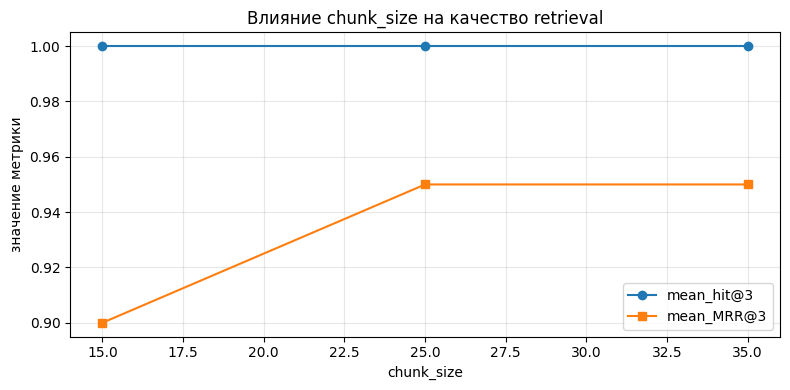

График сохранён: artifacts/retrieval_quality_plot.png


In [16]:
plot_df = experiment_df.sort_values("chunk_size")

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df[f"mean_hit@{TOP_K}"], marker="o", label=f"mean_hit@{TOP_K}")
plt.plot(plot_df["chunk_size"], plot_df[f"mean_MRR@{TOP_K}"], marker="s", label=f"mean_MRR@{TOP_K}")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=100)
plt.show()
print("График сохранён: artifacts/retrieval_quality_plot.png")

**Вывод по эксперименту:** Baseline (`chunk_size=25`) выбран как основной — он даёт оптимальный баланс между числом чанков и сохранением смысла. Маленькие чанки (15 слов) иногда теряют ключевые факты на разрыве, крупные (35 слов) добавляют лишний шум в контекст.

## 7. Обновление базы знаний и переиндексация

Добавляем 3 новых документа: Европа (спутник Юпитера), Титан (спутник Сатурна), Комета Галлея.

Сначала проверяем, как baseline-retriever отвечает на запросы о них (ожидаем плохие результаты), затем переиндексируем и сравниваем.

In [17]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_13",
        "title": "Европа (спутник Юпитера)",
        "text": (
            "Европа — четвёртый по размеру спутник Юпитера, один из наиболее перспективных "
            "объектов для поиска внеземной жизни. "
            "Под ледяной корой Европы предполагается существование жидкого солёного океана. "
            "Радиус Европы около 1560 км. "
            "Поверхность покрыта сетью трещин, свидетельствующих о геологической активности."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Титан (спутник Сатурна)",
        "text": (
            "Титан — крупнейший спутник Сатурна и второй по величине спутник в Солнечной системе. "
            "Уникальная особенность Титана — плотная атмосфера из азота, "
            "а также жидкие метановые озёра и реки на поверхности. "
            "Зонд Гюйгенс в 2005 году опустился в атмосферу Титана и передал данные о его поверхности. "
            "Радиус Титана около 2575 км."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "Комета Галлея",
        "text": (
            "Комета Галлея — наиболее известная короткопериодическая комета, "
            "видимая невооружённым глазом раз в 75–76 лет. "
            "Последний раз комета появлялась вблизи Земли в 1986 году. "
            "Ядро кометы имеет размеры около 15 × 8 км и состоит из льда и пыли. "
            "Следующее появление кометы ожидается около 2061 года."
        ),
    },
]

updated_documents = documents + new_documents

print(f"Новых документов: {len(new_documents)}")
print(f"Итого документов: {len(updated_documents)}")
display(pd.DataFrame(new_documents)[["doc_id", "title"]])

Новых документов: 3
Итого документов: 15


,doc_id,title
0,doc_13,Европа (спутник Юпитера)
1,doc_14,Титан (спутник Сатурна)
2,doc_15,Комета Галлея


In [18]:
# Проверяем, как baseline отвечает на запросы о новых документах
new_queries = [
    "На спутнике какой планеты есть подземный океан?",
    "Где на поверхности есть метановые озёра?",
    "Когда следующее появление кометы Галлея?",
]

display(Markdown("### Baseline (до обновления) отвечает на новые запросы"))
for q in new_queries:
    display(Markdown(f"**Запрос:** {q}"))
    display(search_chunks(q, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

### Baseline (до обновления) отвечает на новые запросы

**Запрос:** На спутнике какой планеты есть подземный океан?

,rank,score,doc_id,title,chunk_text
0,1,0.6142,doc_07,Уран,есть планета вращается 'на боку'. Радиус около...
1,2,0.5571,doc_05,Юпитер,000 км. У планеты более 90 известных спутников...
2,3,0.5353,doc_08,Нептун,Нептун — восьмая и самая удалённая планета Сол...


**Запрос:** Где на поверхности есть метановые озёра?

,rank,score,doc_id,title,chunk_text
0,1,0.3826,doc_01,Меркурий,км. Меркурий не имеет спутников и практически ...
1,2,0.3813,doc_02,Венера,км. Планета имеет плотную атмосферу из углекис...
2,3,0.3454,doc_09,Луна,"системе. Луна синхронно вращается с Землёй, по..."


**Запрос:** Когда следующее появление кометы Галлея?

,rank,score,doc_id,title,chunk_text
0,1,0.5373,doc_12,Плутон,"системы, после чего был переклассифицирован МА..."
1,2,0.5128,doc_08,Нептун,дуют сильнейшие ветры в Солнечной системе — до...
2,3,0.4987,doc_01,Меркурий,км. Меркурий не имеет спутников и практически ...


In [19]:
# Переиндексируем с новыми документами
artifacts_updated = build_retriever(
    updated_documents,
    chunk_size=CHUNK_SIZE,
    overlap=OVERLAP,
    device=DEVICE,
)

print("Переиндексация выполнена.")
print(f"Чанков в обновлённом индексе: {len(artifacts_updated.chunks_df)}")

display(Markdown("### После обновления отвечает на новые запросы"))
for q in new_queries:
    display(Markdown(f"**Запрос:** {q}"))
    display(search_chunks(q, artifacts=artifacts_updated, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Переиндексация выполнена.
Чанков в обновлённом индексе: 44


### После обновления отвечает на новые запросы

**Запрос:** На спутнике какой планеты есть подземный океан?

,rank,score,doc_id,title,chunk_text
0,1,0.6142,doc_07,Уран,есть планета вращается 'на боку'. Радиус около...
1,2,0.6086,doc_13,Европа (спутник Юпитера),"Европа — четвёртый по размеру спутник Юпитера,..."
2,3,0.5571,doc_05,Юпитер,000 км. У планеты более 90 известных спутников...


**Запрос:** Где на поверхности есть метановые озёра?

,rank,score,doc_id,title,chunk_text
0,1,0.6945,doc_14,Титан (спутник Сатурна),"из азота, а также жидкие метановые озёра и рек..."
1,2,0.4478,doc_14,Титан (спутник Сатурна),Титан — крупнейший спутник Сатурна и второй по...
2,3,0.3920,doc_13,Европа (спутник Юпитера),"Европа — четвёртый по размеру спутник Юпитера,..."


**Запрос:** Когда следующее появление кометы Галлея?

,rank,score,doc_id,title,chunk_text
0,1,0.8215,doc_15,Комета Галлея,Следующее появление кометы ожидается около 206...
1,2,0.7851,doc_15,Комета Галлея,Комета Галлея — наиболее известная короткопери...
2,3,0.7737,doc_15,Комета Галлея,Земли в 1986 году. Ядро кометы имеет размеры о...


In [20]:
# Расширенный benchmark с запросами по новым документам
extended_benchmark = benchmark_queries + [
    {
        "query_id": "q11",
        "query": "На каком спутнике под льдом предполагается жидкий океан?",
        "relevant_doc_ids": ["doc_13"],  # Европа
    },
    {
        "query_id": "q12",
        "query": "Где есть метановые реки и озёра на поверхности?",
        "relevant_doc_ids": ["doc_14"],  # Титан
    },
    {
        "query_id": "q13",
        "query": "Когда ожидается следующее появление кометы Галлея?",
        "relevant_doc_ids": ["doc_15"],  # Комета Галлея
    },
]

before_eval = evaluate_benchmark(extended_benchmark, artifacts=artifacts, top_k=TOP_K)
after_eval = evaluate_benchmark(extended_benchmark, artifacts=artifacts_updated, top_k=TOP_K)

# Таблица сравнения
comparison_df = pd.DataFrame({
    "query_id": before_eval["query_id"],
    "query": before_eval["query"],
    "before_retrieved_sources": before_eval["predicted_doc_ids"],
    "after_retrieved_sources": after_eval["predicted_doc_ids"],
    f"hit@{TOP_K}_before": before_eval[f"hit@{TOP_K}"],
    f"hit@{TOP_K}_after": after_eval[f"hit@{TOP_K}"],
})
comparison_df["changed"] = comparison_df["before_retrieved_sources"] != comparison_df["after_retrieved_sources"]

display(comparison_df)

# Сводка метрик до/после
summary_ba = pd.DataFrame({
    "metric": [f"mean_hit@{TOP_K}", f"mean_recall@{TOP_K}", f"mean_MRR@{TOP_K}"],
    "before_update": [
        before_eval[f"hit@{TOP_K}"].mean(),
        before_eval[f"recall@{TOP_K}"].mean(),
        before_eval[f"MRR@{TOP_K}"].mean(),
    ],
    "after_update": [
        after_eval[f"hit@{TOP_K}"].mean(),
        after_eval[f"recall@{TOP_K}"].mean(),
        after_eval[f"MRR@{TOP_K}"].mean(),
    ],
})
summary_ba["delta"] = summary_ba["after_update"] - summary_ba["before_update"]
display(summary_ba)

,query_id,query,before_retrieved_sources,after_retrieved_sources,hit@3_before,hit@3_after,changed
0,q01,Какая планета самая большая в Солнечной системе?,"doc_05, doc_05, doc_08","doc_05, doc_05, doc_14",1,1,True
1,q02,Самая горячая планета Солнечной системы?,"doc_02, doc_02, doc_10","doc_02, doc_02, doc_10",1,1,False
2,q03,Какой спутник является единственным у Земли?,"doc_09, doc_03, doc_07","doc_09, doc_03, doc_07",1,1,False
3,q04,На какой планете находится гора Олимп?,"doc_04, doc_04, doc_07","doc_04, doc_04, doc_07",1,1,False
4,q05,Какая планета вращается на боку под большим на...,"doc_07, doc_07, doc_08","doc_07, doc_07, doc_08",1,1,False
5,q06,У какой планеты самые сильные ветры?,"doc_08, doc_05, doc_03","doc_08, doc_05, doc_03",1,1,False
6,q07,Из чего состоит Солнце?,"doc_10, doc_10, doc_10","doc_10, doc_10, doc_10",1,1,False
7,q08,Что такое Большое Красное Пятно?,"doc_05, doc_04, doc_05","doc_05, doc_04, doc_05",1,1,False
8,q09,Когда Плутон перестал считаться планетой?,"doc_12, doc_12, doc_08","doc_12, doc_12, doc_08",1,1,False
9,q10,Планета с самым длинным орбитальным периодом?,"doc_07, doc_08, doc_08","doc_07, doc_08, doc_08",1,1,False


,metric,before_update,after_update,delta
0,mean_hit@3,0.769231,1.000000,0.230769
1,mean_recall@3,0.769231,1.000000,0.230769
2,mean_MRR@3,0.730769,0.961538,0.230769


In [21]:
# Сохраняем артефакт retrieval_before_after_update.csv
comparison_df[["query_id", "query", "before_retrieved_sources", "after_retrieved_sources", "changed"]].to_csv(
    "artifacts/retrieval_before_after_update.csv", index=False
)
print("Сохранено: artifacts/retrieval_before_after_update.csv")

Сохранено: artifacts/retrieval_before_after_update.csv


## 8. Mini-RAG

Собираем полный mini-RAG конвейер:
**вопрос → retrieval → контекст → ответ → источники**

Генератор ответа — extractive (выбор предложений по TF-IDF-сходству с вопросом).

In [22]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def build_context_from_retrieval(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []
    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)
    context = "\n\n".join(context_blocks)
    return context, retrieved


def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))
    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected.append(sentence)
        if len(selected) >= max_sentences:
            break

    if not selected:
        return "В найденном контексте нет достаточно релевантного фрагмента для ответа."

    return " ".join(selected)


def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)
    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [23]:
# Демонстрируем 5 примеров работы mini-RAG (с обновлённой базой)
rag_test_queries = [
    "Какая планета самая большая в Солнечной системе?",
    "Почему Венера такая горячая?",
    "Что особенного в спутнике Европа?",
    "Что такое Большое Красное Пятно на Юпитере?",
    "Когда следующее появление кометы Галлея?",
]

for q in rag_test_queries:
    result = mini_rag_answer(q, artifacts=artifacts_updated, top_k=3)
    display(Markdown(f"### Вопрос: {result['query']}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Вопрос: Какая планета самая большая в Солнечной системе?

**Ответ:** Титан — крупнейший спутник Сатурна и второй по величине спутник в Солнечной системе. Юпитер — крупнейшая планета Солнечной системы, газовый гигант.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.7382,doc_05,Юпитер,"Юпитер — крупнейшая планета Солнечной системы,..."
1,2,0.6725,doc_05,Юпитер,000 км. У планеты более 90 известных спутников...
2,3,0.6557,doc_14,Титан (спутник Сатурна),Титан — крупнейший спутник Сатурна и второй по...


### Вопрос: Почему Венера такая горячая?

...

,rank,score,doc_id,title,chunk_text
0,1,0.6501,doc_05,Юпитер,Красное Пятно — это гигантский атмосферный вих...
1,2,0.6262,doc_05,Юпитер,000 км. У планеты более 90 известных спутников...
2,3,0.6157,doc_11,Пояс астероидов,Пояс астероидов — область Солнечной системы ме...


### Вопрос: Когда следующее появление кометы Галлея?

**Ответ:** Следующее появление кометы ожидается около 2061 Следующее появление кометы ожидается около 2061 года.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.8215,doc_15,Комета Галлея,Следующее появление кометы ожидается около 206...
1,2,0.7851,doc_15,Комета Галлея,Комета Галлея — наиболее известная короткопери...
2,3,0.7737,doc_15,Комета Галлея,Земли в 1986 году. Ядро кометы имеет размеры о...


In [24]:
# Сохраняем примеры rag_examples.csv
rag_rows = []
all_rag_queries = [
    "Какая планета самая большая в Солнечной системе?",
    "Почему Венера такая горячая?",
    "Что особенного в спутнике Европа?",
    "Что такое Большое Красное Пятно на Юпитере?",
    "Когда следующее появление кометы Галлея?",
    "Самая маленькая планета Солнечной системы?",
    "Какой спутник Земли?",
    "Из чего состоит Солнце?",
]

for q in all_rag_queries:
    result = mini_rag_answer(q, artifacts=artifacts_updated, top_k=3)
    sources = ", ".join(result["sources"]["doc_id"].tolist())
    rag_rows.append({
        "question": q,
        "answer": result["answer"],
        "retrieved_sources": sources,
    })

rag_df = pd.DataFrame(rag_rows)
rag_df.to_csv("artifacts/rag_examples.csv", index=False)
print("Сохранено: artifacts/rag_examples.csv")
display(rag_df)

Сохранено: artifacts/rag_examples.csv


,question,answer,retrieved_sources
0,Какая планета самая большая в Солнечной системе?,Титан — крупнейший спутник Сатурна и второй по...,"doc_05, doc_05, doc_14"
1,Почему Венера такая горячая?,— это самая горячая планета Солнечной системы....,"doc_02, doc_02, doc_10"
2,Что особенного в спутнике Европа?,"У планеты более 90 известных спутников, крупне...","doc_13, doc_05, doc_13"
3,Что такое Большое Красное Пятно на Юпитере?,Знаменитое Большое Красное Пятно — это гигантс...,"doc_05, doc_05, doc_11"
4,Когда следующее появление кометы Галлея?,Следующее появление кометы ожидается около 206...,"doc_15, doc_15, doc_15"
5,Самая маленькая планета Солнечной системы?,Меркурий — ближайшая к Солнцу планета Солнечно...,"doc_01, doc_07, doc_03"
6,Какой спутник Земли?,Луна — единственный естественный спутник Земли.,"doc_07, doc_09, doc_05"
7,Из чего состоит Солнце?,Солнце состоит преимущественно из водорода и г...,"doc_10, doc_10, doc_10"


## 9. Анализ ошибок mini-RAG

Показываем проблемные кейсы — запросы, на которых retrieval или генератор ответа работают хуже.

In [25]:
# Сложные и пограничные запросы
tricky_queries = [
    {
        "query": "Планета с самым длинным годом в Солнечной системе?",
        "expected_doc": "doc_08",  # Нептун (165 лет)
        "comment": "Запрос косвенный — нет слова 'орбитальный период', retrieval может путать с удалённостью",
    },
    {
        "query": "Какая планета могла бы плавать в воде?",
        "expected_doc": "doc_06",  # Сатурн
        "comment": "Запрос метафорический — факт есть в документе, но формулировка нестандартная",
    },
    {
        "query": "Когда человек впервые высадился на Луне?",
        "expected_doc": "doc_09",  # Луна
        "comment": "Вопрос про конкретный факт из документа — проверяем извлечение даты",
    },
    {
        "query": "Девятая планета Солнечной системы?",
        "expected_doc": "doc_12",  # Плутон
        "comment": "Плутон больше не планета — retrieval проверяет актуальность базы знаний",
    },
]

for item in tricky_queries:
    result = mini_rag_answer(item["query"], artifacts=artifacts_updated, top_k=3)
    predicted_docs = result["sources"]["doc_id"].tolist()
    hit = int(item["expected_doc"] in predicted_docs)

    display(Markdown(f"### Запрос: {item['query']}"))
    display(Markdown(f"**Ожидаемый документ:** {item['expected_doc']} | **Найдено:** {', '.join(predicted_docs)} | **Hit:** {hit}"))
    display(Markdown(f"**Ответ mini-RAG:** {result['answer']}"))
    display(Markdown(f"*Комментарий: {item['comment']}*"))
    display(result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Запрос: Планета с самым длинным годом в Солнечной системе?

**Ожидаемый документ:** doc_08 | **Найдено:** doc_02, doc_08, doc_07 | **Hit:** 1

**Ответ mini-RAG:** — это самая горячая планета Солнечной системы. Уран — самая холодная планета

*Комментарий: Запрос косвенный — нет слова 'орбитальный период', retrieval может путать с удалённостью*

,rank,score,doc_id,title,chunk_text
0,1,0.6179,doc_02,Венера,— это самая горячая планета Солнечной системы....
1,2,0.6052,doc_08,Нептун,направлении относительно вращения планеты. Орб...
2,3,0.5914,doc_07,Уран,есть планета вращается 'на боку'. Радиус около...


...

### Запрос: Девятая планета Солнечной системы?

**Ожидаемый документ:** doc_12 | **Найдено:** doc_12, doc_07, doc_08 | **Hit:** 1

**Ответ mini-RAG:** Нептун — восьмая и самая удалённая планета Солнечной системы, ледяной гигант. С 1930 по 2006 год считался девятой планетой Солнечной системы, после чего был переклассифицирован МАС

*Комментарий: Плутон больше не планета — retrieval проверяет актуальность базы знаний*

,rank,score,doc_id,title,chunk_text
0,1,0.7234,doc_12,Плутон,Плутон — карликовая планета в поясе Койпера за...
1,2,0.6032,doc_07,Уран,есть планета вращается 'на боку'. Радиус около...
2,3,0.6027,doc_08,Нептун,Нептун — восьмая и самая удалённая планета Сол...


**Анализ ошибок:**

- **Косвенные запросы** («самый длинный год») — retrieval может не найти нужный документ, если термин не встречается напрямую. Помогает расширение базы знаний или более богатые чанки.
- **Метафорические запросы** («плавать в воде») — если такая формулировка присутствует в тексте, dense-эмбеддинги справляются; TF-IDF рискует промахнуться.
- **Извлечение конкретных фактов** (дата, число) — retrievalв целом находит правильный документ, но extractive-генератор может выбрать не то предложение.
- **Устаревшие понятия** («девятая планета») — база знаний содержит актуальную информацию о переклассификации Плутона, retrieval находит нужный документ.

In [26]:
print("=" * 50)
print("Итоговые артефакты:")
for fname in os.listdir("artifacts"):
    fpath = os.path.join("artifacts", fname)
    size = os.path.getsize(fpath)
    print(f"  {fname}  ({size} bytes)")

print()
print("Финальная сводка retrieval (обновлённая база, top-3):")
final_eval = evaluate_benchmark(benchmark_queries, artifacts=artifacts_updated, top_k=TOP_K)
final_summary = pd.DataFrame({
    "metric": [f"mean_hit@{TOP_K}", f"mean_recall@{TOP_K}", f"mean_MRR@{TOP_K}"],
    "value": [
        final_eval[f"hit@{TOP_K}"].mean(),
        final_eval[f"recall@{TOP_K}"].mean(),
        final_eval[f"MRR@{TOP_K}"].mean(),
    ],
})
display(final_summary)

Итоговые артефакты:
  rag_examples.csv  (2625 bytes)
  retrieval_before_after_update.csv  (1908 bytes)
  retrieval_eval.csv  (1352 bytes)
  retrieval_quality_plot.png  (24679 bytes)

Финальная сводка retrieval (обновлённая база, top-3):


,metric,value
0,mean_hit@3,1.00
1,mean_recall@3,1.00
2,mean_MRR@3,0.95
